# EllipticGuard Diagnostics
## Temporal drift and graph label signal

This notebook evaluates:
1. feature drift across the time-forward split with KS statistics;
2. label concentration in the training graph.

Split: train `t=1–34`, val `t=35–41`, test `t=42–49`.  
`UNKNOWN` nodes are excluded from supervised metrics.

## 0) Setup

Set `TX_PATH` to the processed graph file.

In [ ]:
PROJECT_DIR = '..'
TX_PATH = f'{PROJECT_DIR}/Dataset/processed/transaction_graph_v1.pt'

## 1) Dependencies
Install the required packages and load the analysis stack.

In [ ]:
!pip -q install pandas numpy matplotlib scikit-learn scipy tqdm
!pip -q install 'torch-geometric==2.5.3'

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.stats import ks_2samp
from sklearn.metrics import average_precision_score, roc_auc_score
from tqdm.auto import tqdm

LICIT, ILLICIT, UNKNOWN = 0, 1, 2

RNG = np.random.default_rng(42)

## 2) Load processed graph
Load `x`, `edge_index`, and `y` from the processed transaction graph.

In [4]:
obj = torch.load(TX_PATH, weights_only=False, map_location='cpu')
data_dict = obj[0]
x = data_dict['x']
edge_index = data_dict['edge_index']
y = data_dict['y']


N = int(x.shape[0])
E = int(edge_index.shape[1])

print('N nodes:', f'{N:,}')
print('E edges:', f'{E:,}')
print('x dtype:', x.dtype, '| y dtype:', y.dtype, '| edge_index dtype:', edge_index.dtype)

# Time step
t_raw = x[:, 0].long()
print('time step min/max:', int(t_raw.min()), int(t_raw.max()))

# Label counts
uniq, cnt = torch.unique(y, return_counts=True)
print('Label counts:', dict(zip(uniq.tolist(), cnt.tolist())))


N nodes: 203,769
E edges: 234,355
x dtype: torch.float32 | y dtype: torch.int64 | edge_index dtype: torch.int64
time step min/max: 1 49
Label counts: {0: 42019, 1: 4545, 2: 157205}


## 3) Time-forward split
Use train `1–34`, validation `35–41`, and test `42–49`.  

In [5]:
t = t_raw
t_np = t.numpy()

# Node masks by time block (ALL nodes)
train_block = (t_np >= 1) & (t_np <= 34)
val_block   = (t_np >= 35) & (t_np <= 41)
test_block  = (t_np >= 42) & (t_np <= 49)

# Labeled mask
y_np = y.numpy()
labeled_mask = (y_np != UNKNOWN)

train_labeled = train_block & labeled_mask
val_labeled   = val_block & labeled_mask
test_labeled  = test_block & labeled_mask

def block_stats(name, m):
    m = m.astype(bool)
    n_all = int(m.sum())
    n_lab = int((m & labeled_mask).sum())
    yy = y_np[m & labeled_mask]
    n_il = int((yy == ILLICIT).sum())
    n_li = int((yy == LICIT).sum())
    rate = n_il / max(1, (n_il + n_li))
    ts = np.unique(t_np[m])
    print(f'{name}: all={n_all:,} | labeled={n_lab:,} (licit={n_li:,}, illicit={n_il:,}, illicit_rate={rate:.4f}) | t={ts.min()}..{ts.max()}')

block_stats('TRAIN', train_block)
block_stats('VAL  ', val_block)
block_stats('TEST ', test_block)


TRAIN: all=136,265 | labeled=29,894 (licit=26,432, illicit=3,462, illicit_rate=0.1158) | t=1..34
VAL  : all=30,680 | labeled=7,829 (licit=7,154, illicit=675, illicit_rate=0.0862) | t=35..41
TEST : all=36,824 | labeled=8,841 (licit=8,433, illicit=408, illicit_rate=0.0461) | t=42..49


### Split takeaway
The labeled class mix shifts over time. The illicit share falls from `11.58%` in train to `8.62%` in validation and `4.61%` in test.

## 4) Feature drift with KS statistics
Compute feature-wise KS statistics for train vs validation and train vs test on labeled nodes only. The time column is excluded.

In [6]:
# Extract the 165 non-time features as numpy
X = x[:, 1:].numpy()  # shape [N,165]

X_train = X[train_labeled]
X_val   = X[val_labeled]
X_test  = X[test_labeled]

print('Shapes (labeled only):')
print('  X_train:', X_train.shape)
print('  X_val  :', X_val.shape)
print('  X_test :', X_test.shape)

def ks_featurewise(A: np.ndarray, B: np.ndarray, *, feature_names=None, max_samples=None, rng=None):
    """Compute KS statistic per feature (columns).

    Args:
        A, B: arrays shaped [n_samples, n_features]
        feature_names: optional list of length n_features
        max_samples: if set (e.g., 50000), subsample each split to speed up KS computation
        rng: numpy Generator for subsampling
    """
    if rng is None:
        rng = np.random.default_rng(0)

    def _subsample(X):
        if (max_samples is None) or (X.shape[0] <= max_samples):
            return X
        idx = rng.choice(X.shape[0], size=max_samples, replace=False)
        return X[idx]

    A2 = _subsample(A)
    B2 = _subsample(B)

    p = A2.shape[1]
    stats = np.empty(p, dtype=float)
    pvals = np.empty(p, dtype=float)

    for j in tqdm(range(p), desc='KS per feature'):
        res = ks_2samp(A2[:, j], B2[:, j], alternative='two-sided', mode='auto')
        stats[j] = res.statistic
        pvals[j] = res.pvalue

    if feature_names is None:
        feature_names = [f'feature_{j+1}' for j in range(p)]  # 1..165 for x[:,1:]
    df = pd.DataFrame({
        'feature': feature_names,
        'ks_stat': stats,
        'ks_pvalue': pvals,
        'n_A': A.shape[0],
        'n_B': B.shape[0],
        'n_A_used': A2.shape[0],
        'n_B_used': B2.shape[0],
    })
    return df


feature_names = [f'feature_{j+1}' for j in range(X.shape[1])]

# Optional
MAX_SAMPLES = None

print('Computing KS(train vs val) ...')
df_ks_tv = ks_featurewise(X_train, X_val, feature_names=feature_names, max_samples=MAX_SAMPLES, rng=RNG).rename(columns={'ks_stat':'ks_train_val','ks_pvalue':'p_train_val'})

print('Computing KS(train vs test) ...')
df_ks_tt = ks_featurewise(X_train, X_test, feature_names=feature_names, max_samples=MAX_SAMPLES, rng=RNG).rename(columns={'ks_stat':'ks_train_test','ks_pvalue':'p_train_test'})

df_ks = df_ks_tv.merge(df_ks_tt[['feature','ks_train_test','p_train_test']], on='feature', how='inner')

# Convenience: max drift across the two future comparisons
df_ks['ks_max'] = df_ks[['ks_train_val','ks_train_test']].max(axis=1)

df_ks.sort_values('ks_max', ascending=False).head(10)


Shapes (labeled only):
  X_train: (29894, 165)
  X_val  : (7829, 165)
  X_test : (8841, 165)
Computing KS(train vs val) ...


KS per feature:   0%|          | 0/165 [00:00<?, ?it/s]

Computing KS(train vs test) ...


KS per feature:   0%|          | 0/165 [00:00<?, ?it/s]

,feature,ks_train_val,p_train_val,n_A,n_B,n_A_used,n_B_used,ks_train_test,p_train_test,ks_max
100,feature_101,0.992081,0.0,29894,7829,29894,7829,0.998982,0.0,0.998982
102,feature_103,0.990931,0.0,29894,7829,29894,7829,0.998303,0.0,0.998303
135,feature_136,0.992589,0.0,29894,7829,29894,7829,0.997319,0.0,0.997319
99,feature_100,0.989526,0.0,29894,7829,29894,7829,0.996267,0.0,0.996267
138,feature_139,0.958301,0.0,29894,7829,29894,7829,0.978352,0.0,0.978352
136,feature_137,0.926020,0.0,29894,7829,29894,7829,0.939883,0.0,0.939883
1,feature_2,0.685372,0.0,29894,7829,29894,7829,0.634584,0.0,0.685372
105,feature_106,0.666585,0.0,29894,7829,29894,7829,0.543183,0.0,0.666585
108,feature_109,0.609302,0.0,29894,7829,29894,7829,0.529332,0.0,0.609302
141,feature_142,0.531035,0.0,29894,7829,29894,7829,0.464795,0.0,0.531035


In [7]:
# Summary statistics
summary = df_ks[['ks_train_val','ks_train_test','ks_max']].describe(percentiles=[0.5,0.75,0.9,0.95,0.99]).T
summary


,count,mean,std,min,50%,75%,90%,95%,99%,max
ks_train_val,165.0,0.177099,0.193142,0.000119,0.117487,0.169476,0.354091,0.593648,0.991345,0.992589
ks_train_test,165.0,0.180019,0.193623,0.000969,0.121725,0.183231,0.384034,0.524821,0.997673,0.998982
ks_max,165.0,0.198100,0.191978,0.000969,0.139771,0.201783,0.384034,0.593648,0.997673,0.998982


In [8]:
# Optional: summarize drift by feature group (local vs aggregate)
# Based on dataset description: 93 local features + 72 aggregate features = 165 non-time features.
# Here: feature_1...feature_93 -> local, feature_94...feature_165 -> aggregate.

def feature_group(feat_name: str) -> str:
    k = int(feat_name.split('_')[1])
    return 'local(1-93)' if k <= 93 else 'aggregate(94-165)'

df_ks['group'] = df_ks['feature'].apply(feature_group)

def q(x, p):
    return np.quantile(x, p)

group_summary = df_ks.groupby('group').agg(
    n_features=('feature','count'),
    ks_test_mean=('ks_train_test','mean'),
    ks_test_median=('ks_train_test','median'),
    ks_test_p90=('ks_train_test', lambda s: q(s, 0.90)),
    ks_test_p95=('ks_train_test', lambda s: q(s, 0.95)),
    ks_max_mean=('ks_max','mean'),
    ks_max_median=('ks_max','median'),
)
group_summary


,n_features,ks_test_mean,ks_test_median,ks_test_p90,ks_test_p95,ks_max_mean,ks_max_median
group,,,,,,,
aggregate(94-165),72,0.246185,0.140355,0.527076,0.986414,0.263819,0.154361
local(1-93),93,0.128794,0.118157,0.204204,0.219530,0.147220,0.129529


In [9]:
# Show most drifting and most stable features
top_k = 20

print('Most drifting features (by ks_max):')
display(df_ks.sort_values('ks_max', ascending=False).head(top_k))

print('\nMost stable features (by ks_max):')
display(df_ks.sort_values('ks_max', ascending=True).head(top_k))


Most drifting features (by ks_max):


,feature,ks_train_val,p_train_val,n_A,n_B,n_A_used,n_B_used,ks_train_test,p_train_test,ks_max,group
100,feature_101,0.992081,0.0,29894,7829,29894,7829,0.998982,0.0,0.998982,aggregate(94-165)
102,feature_103,0.990931,0.0,29894,7829,29894,7829,0.998303,0.0,0.998303,aggregate(94-165)
135,feature_136,0.992589,0.0,29894,7829,29894,7829,0.997319,0.0,0.997319,aggregate(94-165)
99,feature_100,0.989526,0.0,29894,7829,29894,7829,0.996267,0.0,0.996267,aggregate(94-165)
138,feature_139,0.958301,0.0,29894,7829,29894,7829,0.978352,0.0,0.978352,aggregate(94-165)
136,feature_137,0.926020,0.0,29894,7829,29894,7829,0.939883,0.0,0.939883,aggregate(94-165)
1,feature_2,0.685372,0.0,29894,7829,29894,7829,0.634584,0.0,0.685372,local(1-93)
105,feature_106,0.666585,0.0,29894,7829,29894,7829,0.543183,0.0,0.666585,aggregate(94-165)
108,feature_109,0.609302,0.0,29894,7829,29894,7829,0.529332,0.0,0.609302,aggregate(94-165)
141,feature_142,0.531035,0.0,29894,7829,29894,7829,0.464795,0.0,0.531035,aggregate(94-165)



Most stable features (by ks_max):


,feature,ks_train_val,p_train_val,n_A,n_B,n_A_used,n_B_used,ks_train_test,p_train_test,ks_max,group
14,feature_15,0.000119,1.000000e+00,29894,7829,29894,7829,0.000969,1.000000e+00,0.000969,local(1-93)
6,feature_7,0.015240,1.109006e-01,29894,7829,29894,7829,0.012397,2.431132e-01,0.015240,local(1-93)
69,feature_70,0.013015,2.419487e-01,29894,7829,29894,7829,0.019039,1.403464e-02,0.019039,local(1-93)
115,feature_116,0.035178,4.175702e-07,29894,7829,29894,7829,0.014580,1.088644e-01,0.035178,aggregate(94-165)
116,feature_117,0.035563,2.976189e-07,29894,7829,29894,7829,0.014747,1.018071e-01,0.035563,aggregate(94-165)
37,feature_38,0.053202,1.056202e-15,29894,7829,29894,7829,0.043055,1.988677e-11,0.053202,local(1-93)
38,feature_39,0.053443,7.681528e-16,29894,7829,29894,7829,0.043862,7.622435e-12,0.053443,local(1-93)
128,feature_129,0.055910,2.686019e-17,29894,7829,29894,7829,0.034419,1.856684e-07,0.055910,aggregate(94-165)
127,feature_128,0.056673,9.224831e-18,29894,7829,29894,7829,0.034712,1.407676e-07,0.056673,aggregate(94-165)
110,feature_111,0.060028,7.095731e-20,29894,7829,29894,7829,0.026889,1.017895e-04,0.060028,aggregate(94-165)


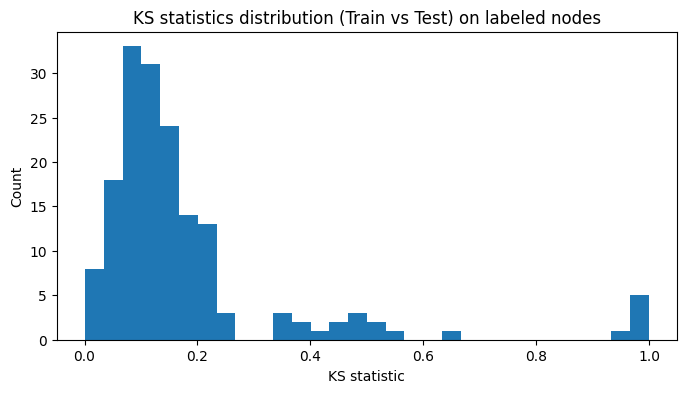

In [10]:
# Histogram of KS values (train vs test) to summarize drift magnitude
plt.figure(figsize=(8,4))
plt.hist(df_ks['ks_train_test'].values, bins=30)
plt.title('KS statistics distribution (Train vs Test) on labeled nodes')
plt.xlabel('KS statistic')
plt.ylabel('Count')
plt.show()


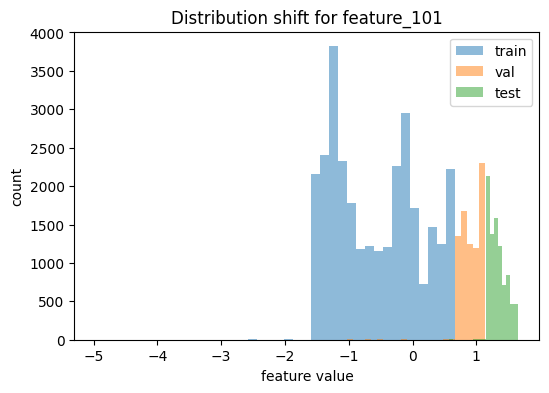

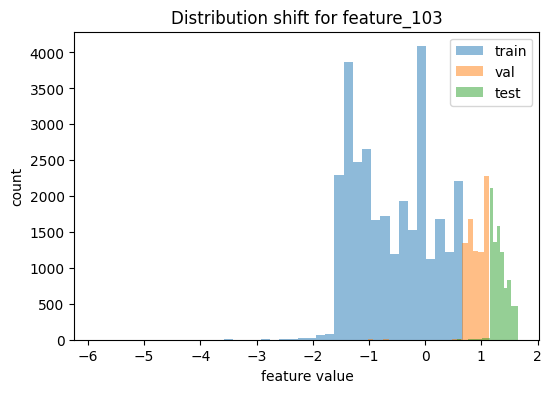

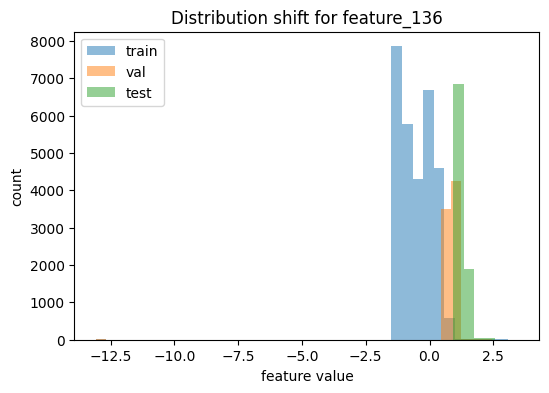

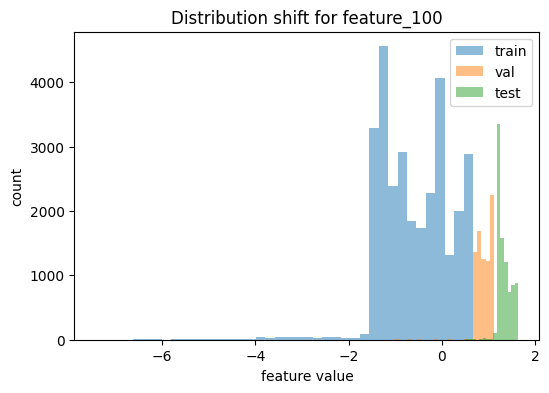

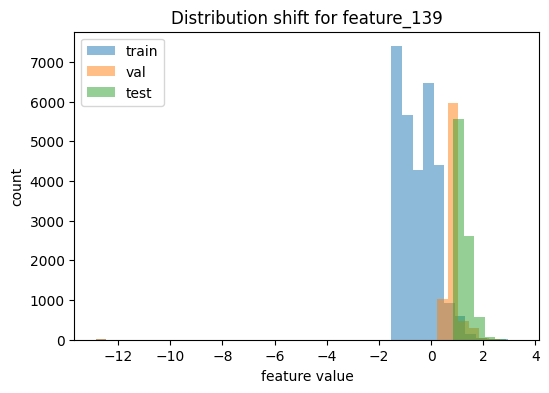

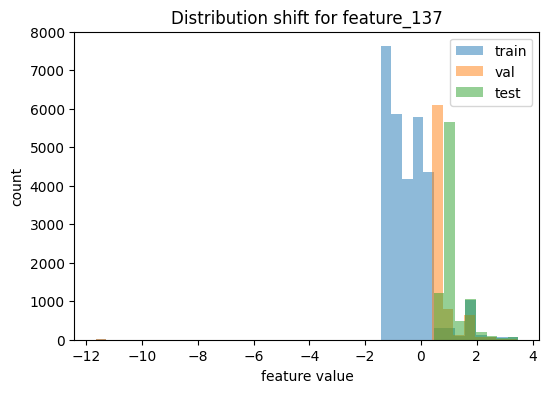

In [11]:
# Inspect the highest-drift features

top_drift_features = [
    "feature_101",
    "feature_103",
    "feature_136",
    "feature_100",
    "feature_139",
    "feature_137"
]


feature_index = {f"feature_{i+1}": i for i in range(165)}

for feat in top_drift_features:

    idx = feature_index[feat]

    train_vals = X[train_labeled, idx]
    val_vals   = X[val_labeled, idx]
    test_vals  = X[test_labeled, idx]

    plt.figure(figsize=(6,4))

    plt.hist(train_vals, bins=40, alpha=0.5, label="train")
    plt.hist(val_vals, bins=40, alpha=0.5, label="val")
    plt.hist(test_vals, bins=40, alpha=0.5, label="test")

    plt.title(f"Distribution shift for {feat}")
    plt.xlabel("feature value")
    plt.ylabel("count")
    plt.legend()

    plt.show()

### Drift takeaway
Temporal drift is substantial. Median `KS(train,test)` is `0.122`, the 90th percentile is `0.384`, and the largest shifts are concentrated in aggregate features. Aggregate features drift more than local ones (`mean KS_train_test = 0.246` vs `0.129`). The strongest drift appears in `feature_100`, `feature_101`, `feature_103`, `feature_136`, `feature_137`, and `feature_139`, all with `KS` close to `1`.

## 5) Graph label signal in the training block
Measure labeled-neighbor coverage, illicit-neighbor fraction, and same-class concentration on the training subgraph. Results are reported for undirected, in-neighbor, and out-neighbor views.

In [12]:
# Torch tensors for efficient aggregation
t_train = torch.from_numpy(train_block).bool()
y_t = y.long()

src = edge_index[0].long()
dst = edge_index[1].long()

# Restrict to edges fully inside the TRAIN time block (safe even if cross-time edges exist)
edge_in_train = t_train[src] & t_train[dst]
src_tr = src[edge_in_train]
dst_tr = dst[edge_in_train]

print('Edges inside TRAIN block:', int(edge_in_train.sum()))

# Convenience masks on nodes
node_in_train = t_train
node_train_labeled = node_in_train & (y_t != UNKNOWN)

print('Train labeled nodes:', int(node_train_labeled.sum()))

Edges inside TRAIN block: 156843
Train labeled nodes: 29894


In [13]:
def neighbor_label_features_directed(src_idx: torch.Tensor, dst_idx: torch.Tensor, y: torch.Tensor, N: int):
    """For directed edges (src -> dst), compute in-neighbor and out-neighbor labeled/illicit counts."""
    # In-neighbors: for each dst, look at labels of src
    src_labeled = (y[src_idx] != UNKNOWN).long()
    src_illicit = (y[src_idx] == ILLICIT).long()

    in_labeled = torch.zeros(N, dtype=torch.long)
    in_illicit = torch.zeros(N, dtype=torch.long)
    in_labeled.scatter_add_(0, dst_idx, src_labeled)
    in_illicit.scatter_add_(0, dst_idx, src_illicit)

    # Out-neighbors: for each src, look at labels of dst
    dst_labeled = (y[dst_idx] != UNKNOWN).long()
    dst_illicit = (y[dst_idx] == ILLICIT).long()

    out_labeled = torch.zeros(N, dtype=torch.long)
    out_illicit = torch.zeros(N, dtype=torch.long)
    out_labeled.scatter_add_(0, src_idx, dst_labeled)
    out_illicit.scatter_add_(0, src_idx, dst_illicit)

    return (in_labeled, in_illicit, out_labeled, out_illicit)

def neighbor_label_features_undirected(src_idx: torch.Tensor, dst_idx: torch.Tensor, y: torch.Tensor, N: int):
    """Treat directed edges as undirected by adding reverse edges, then aggregate neighbor labels."""
    src_u = torch.cat([src_idx, dst_idx], dim=0)
    dst_u = torch.cat([dst_idx, src_idx], dim=0)

    neigh_labeled = (y[src_u] != UNKNOWN).long()
    neigh_illicit = (y[src_u] == ILLICIT).long()

    labeled_cnt = torch.zeros(N, dtype=torch.long)
    illicit_cnt = torch.zeros(N, dtype=torch.long)
    labeled_cnt.scatter_add_(0, dst_u, neigh_labeled)
    illicit_cnt.scatter_add_(0, dst_u, neigh_illicit)

    return labeled_cnt, illicit_cnt

# Compute features on TRAIN subgraph
in_lab, in_il, out_lab, out_il = neighbor_label_features_directed(src_tr, dst_tr, y_t, N)
und_lab, und_il = neighbor_label_features_undirected(src_tr, dst_tr, y_t, N)

# Fractions (float); use NaN where denominator = 0
def safe_frac(num: torch.Tensor, den: torch.Tensor):
    den_f = den.float()
    out = num.float() / torch.where(den_f > 0, den_f, torch.ones_like(den_f))
    out = out.numpy()
    out[den.numpy() == 0] = np.nan
    return out

frac_in  = safe_frac(in_il, in_lab)
frac_out = safe_frac(out_il, out_lab)
frac_und = safe_frac(und_il, und_lab)

In [14]:
# Build a diagnostic dataframe for TRAIN labeled nodes
train_idx = np.where(train_labeled)[0]

diag = pd.DataFrame({
    'node_id': train_idx,
    'label': y_np[train_idx],
    'in_labeled_neighbors': in_lab.numpy()[train_idx],
    'in_illicit_neighbors': in_il.numpy()[train_idx],
    'out_labeled_neighbors': out_lab.numpy()[train_idx],
    'out_illicit_neighbors': out_il.numpy()[train_idx],
    'und_labeled_neighbors': und_lab.numpy()[train_idx],
    'und_illicit_neighbors': und_il.numpy()[train_idx],
    'frac_in': frac_in[train_idx],
    'frac_out': frac_out[train_idx],
    'frac_und': frac_und[train_idx],
})

diag['is_illicit'] = (diag['label'] == ILLICIT).astype(int)

diag.head()


,node_id,label,in_labeled_neighbors,in_illicit_neighbors,out_labeled_neighbors,out_illicit_neighbors,und_labeled_neighbors,und_illicit_neighbors,frac_in,frac_out,frac_und,is_illicit
0,3,0,61,1,1,0,62,1,0.016393,0.0,0.016129,0
1,9,0,22,0,1,0,23,0,0.000000,0.0,0.000000,0
2,10,0,0,0,2,0,2,0,NaN,0.0,0.000000,0
3,11,0,1,0,1,0,2,0,0.000000,0.0,0.000000,0
4,16,0,1,0,1,0,2,0,0.000000,0.0,0.000000,0


In [15]:
# Coverage: how many labeled TRAIN nodes have at least one labeled neighbor?
cov_in  = np.mean(diag['in_labeled_neighbors'].values > 0)
cov_out = np.mean(diag['out_labeled_neighbors'].values > 0)
cov_und = np.mean(diag['und_labeled_neighbors'].values > 0)

print(f'Coverage (TRAIN labeled nodes):')
print(f'  in-neighbor labeled coverage : {cov_in:.3f}')
print(f'  out-neighbor labeled coverage: {cov_out:.3f}')
print(f'  undirected labeled coverage  : {cov_und:.3f}')

print('\nNeighbor labeled count summary (undirected):')
display(diag['und_labeled_neighbors'].describe(percentiles=[0.5,0.75,0.9,0.95,0.99]))


Coverage (TRAIN labeled nodes):
  in-neighbor labeled coverage : 0.494
  out-neighbor labeled coverage: 0.567
  undirected labeled coverage  : 0.785

Neighbor labeled count summary (undirected):


,und_labeled_neighbors
count,29894.000000
mean,1.531946
std,3.676426
min,0.000000
50%,1.000000
75%,2.000000
90%,3.000000
95%,4.000000
99%,9.000000
max,453.000000


In [16]:
# Single-feature PR-AUC using neighbor illicit fraction (only where defined)
def pr_auc_from_score(df: pd.DataFrame, score_col: str):
    m = df[score_col].notna().values
    y_true = df.loc[m, 'is_illicit'].values
    y_score = df.loc[m, score_col].values
    ap = average_precision_score(y_true, y_score)
    return ap, int(m.sum()), float(m.mean())

for col in ['frac_und','frac_in','frac_out']:
    ap, n_used, used_frac = pr_auc_from_score(diag, col)
    print(f'PR-AUC using {col}: {ap:.4f} | nodes_used={n_used:,} ({used_frac:.3%} of TRAIN labeled)')

# Optional: ROC-AUC (only meaningful when both classes present in subset)
for col in ['frac_und','frac_in','frac_out']:
    m = diag[col].notna().values
    y_true = diag.loc[m, 'is_illicit'].values
    y_score = diag.loc[m, col].values
    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_score)
        print(f'ROC-AUC using {col}: {auc:.4f}')


PR-AUC using frac_und: 0.4797 | nodes_used=23,479 (78.541% of TRAIN labeled)
PR-AUC using frac_in: 0.6837 | nodes_used=14,754 (49.354% of TRAIN labeled)
PR-AUC using frac_out: 0.4588 | nodes_used=16,957 (56.724% of TRAIN labeled)
ROC-AUC using frac_und: 0.7800
ROC-AUC using frac_in: 0.8488
ROC-AUC using frac_out: 0.7886


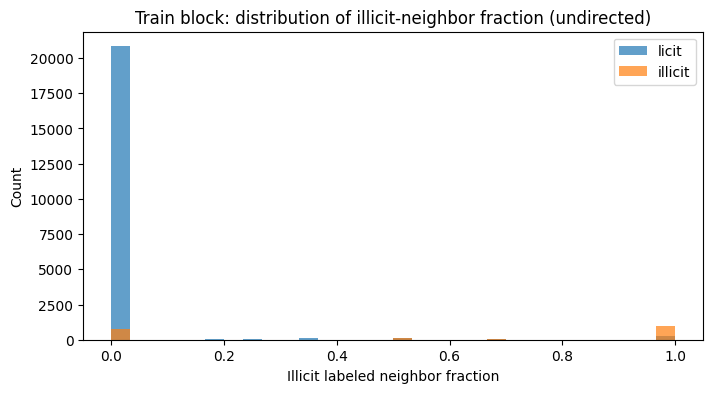

In [17]:
# Distribution separation: neighbor illicit fraction for licit vs illicit (undirected)
plt.figure(figsize=(8,4))
plt.hist(diag.loc[diag['is_illicit']==0, 'frac_und'].dropna().values, bins=30, alpha=0.7, label='licit')
plt.hist(diag.loc[diag['is_illicit']==1, 'frac_und'].dropna().values, bins=30, alpha=0.7, label='illicit')
plt.title('Train block: distribution of illicit-neighbor fraction (undirected)')
plt.xlabel('Illicit labeled neighbor fraction')
plt.ylabel('Count')
plt.legend()
plt.show()


In [18]:
# Labeled-to-labeled edge same-class concentration (TRAIN block only)
y_src = y_t[src_tr]
y_dst = y_t[dst_tr]

edge_labeled = (y_src != UNKNOWN) & (y_dst != UNKNOWN)
n_lab_edges = int(edge_labeled.sum())

same = (y_src[edge_labeled] == y_dst[edge_labeled])
same_rate = float(same.float().mean()) if n_lab_edges > 0 else float('nan')

print('TRAIN block labeled-to-labeled edges:', f'{n_lab_edges:,}')
print('Same-class rate on labeled-to-labeled edges:', f'{same_rate:.4f}')

# Break down by pair type
pairs = pd.crosstab(
    y_src[edge_labeled].numpy(),
    y_dst[edge_labeled].numpy(),
    rownames=['src_label'], colnames=['dst_label']
)
display(pairs)


TRAIN block labeled-to-labeled edges: 22,898
Same-class rate on labeled-to-labeled edges: 0.9472


dst_label,0,1
src_label,,
0,20851,562
1,646,839


### Graph-signal takeaway
The training graph shows strong label concentration. Undirected labeled-neighbor coverage is `78.5%`, same-class rate on labeled-to-labeled train edges is `94.72%`, and the in-neighbor illicit fraction is the strongest simple signal (`PR-AUC = 0.684`, `ROC-AUC = 0.849`). These are diagnostics, not deployable features.

## 6) Summary

This notebook reports:
1. feature-wise KS drift for train vs validation and train vs test;
2. drift patterns across local and aggregate features;
3. labeled-neighbor coverage in the training block;
4. PR-AUC / ROC-AUC from illicit-neighbor fraction diagnostics;
5. same-class concentration on labeled-to-labeled training edges.

Together, these diagnostics show whether temporal drift is substantial and whether the training graph contains meaningful local label signal.